<a href="https://colab.research.google.com/github/Prajwal-Luitel/Twitter-Sentiment-Analysis/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
!pip install kagglehub[pandas-datasets]

In [11]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "twitter_training.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
First 5 records:    2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [35]:
df.columns=['id','information','label','tweet']
df.head()

,id,information,label,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


# EDA

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74681 non-null  int64 
 1   information  74681 non-null  object
 2   label        74681 non-null  object
 3   tweet        73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [37]:
df.dropna(inplace=True)

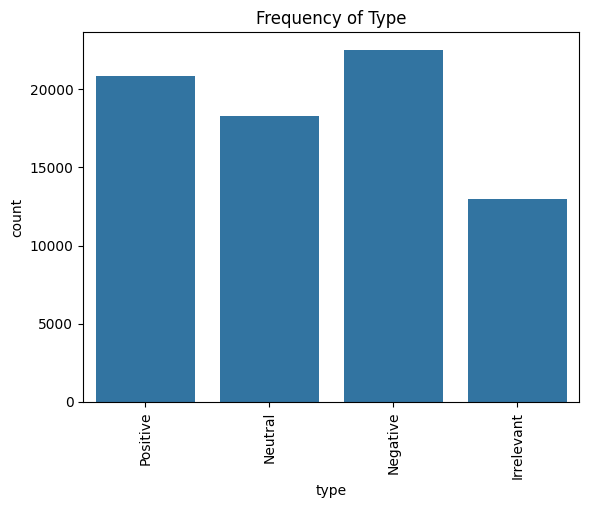

In [28]:
sns.countplot(data=df, x="tweet")
plt.xticks(rotation=90)
plt.title("Frequency of Type")
plt.show()


In [44]:
plot=df.groupby(by=["information","label"]).count().reset_index()
plot.head()

,information,label,id,tweet
0,Amazon,Irrelevant,186,186
1,Amazon,Negative,575,575
2,Amazon,Neutral,1207,1207
3,Amazon,Positive,308,308
4,ApexLegends,Irrelevant,192,192


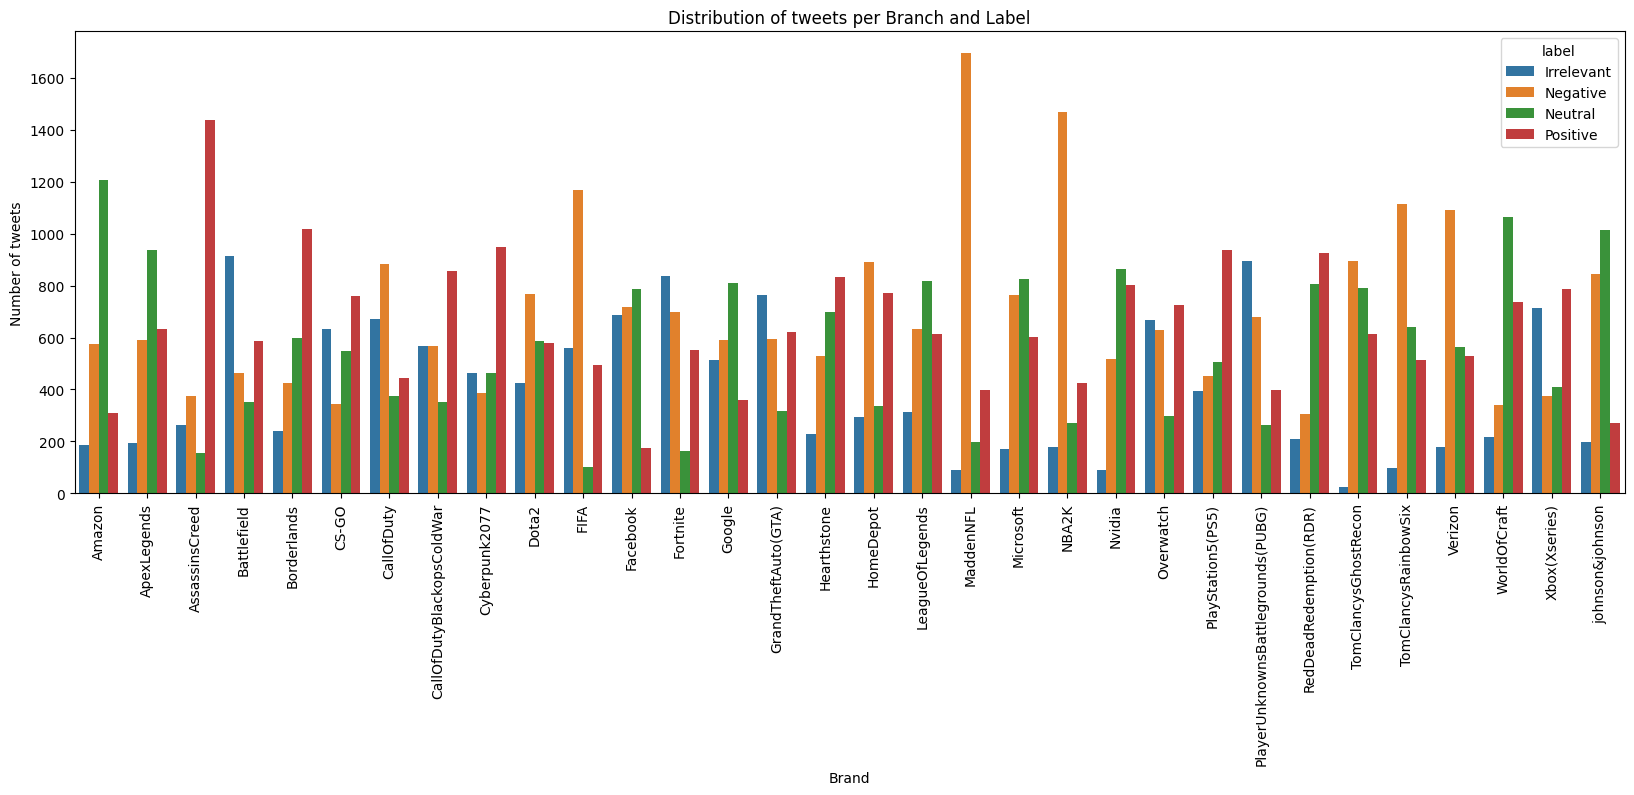

In [42]:
#Figure of comparison per label
plt.figure(figsize=(20,6))
sns.barplot(data=plot,x="information",y="id",hue="label")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.title("Distribution of tweets per Branch and Label");

In [46]:
from wordcloud import WordCloud #Word visualization